# РТ ОМО 3 Супонова София

## Задание 1

In [19]:
def qZ (x, y):
    return (x - 2 * y - 3) / (x ** 2 + 3 * y ** 2 + 1)
def qSumZ(Z):
    return sum(Z)

In [20]:
def exchangeScheme(oldX, oldY, sortedId):
    X = [0 for i in range(4)]
    Y = [0 for i in range(4)]
    X[2] = oldX[sortedId[2]]
    X[3] = oldX[sortedId[2]]
    X[0] = oldX[sortedId[0]]
    X[1] = oldX[sortedId[1]]
    Y[0] = oldY[sortedId[2]]
    Y[1] = oldY[sortedId[2]]
    Y[2] = oldY[sortedId[0]]
    Y[3] = oldY[sortedId[1]]
    return X, Y

In [21]:
def sorting(Z):
    sortedId = sorted(range(len(Z)), key= lambda k: Z[k])
    return sortedId

In [22]:
def evoStep(X, Y, Z):
    _, minId = min((value, id) for (id, value) in enumerate(Z))
    X = X[:]
    Y = Y[:]
    Z = Z[:]
    X.pop(minId)
    Y.pop(minId)
    Z.pop(minId)
    return X, Y, Z

In [23]:
def evoSteps(X, Y, stepsNum = 4):
    results = []
    for i in range(4):
        arrZ = [qZ(x, Y[i]) for i, x in enumerate(X)]
        X, Y, Z = evoStep(X, Y, arrZ)
        X, Y = exchangeScheme(X, Y, sorting(Z))
        results.append([X, Y, qSumZ(arrZ), arrZ])
    return X, Y, results

In [24]:
X = [-4, -2, 0, 2]
Y = [-1, 1, 0, -2]

results = evoSteps(X, Y)

In [25]:
for i in range(len(results[2])):
    print(f'max_{i + 1}_step: {results[2][i][2]}')
qualityArrZ = []
for i in range(len(results[2])):
    qualityArrZ += results[2][i][3]
print(f'max Z:    {max(qualityArrZ)}')

max_1_step: -3.948529411764706
max_2_step: -0.41227180527383367
max_3_step: -0.2720588235294117
max_4_step: 0.37449290060851925
max Z:    0.17647058823529413


## Задание 2

In [26]:
import networkx as nx
from math import e

In [27]:
distances = [(1, 2, 20),
    (1, 3, 40),
    (1, 4, 42),
    (1, 5, 33),
    (1, 6, 21),
    (2, 3, 26),
    (2, 4, 38),
    (2, 5, 42),
    (2, 6, 17),
    (3, 4, 22),
    (3, 5, 43),
    (3, 6, 21),
    (4, 5, 27),
    (4, 6, 22),
    (5, 6, 26)]

V = [1, 4, 5, 2, 6, 3, 1]
Z = [(3, 4),
    (4, 6),
    (5, 2),
    (6, 2)]
P = [49, 54, 43, 54]
T = 100

In [28]:
def probability(delta, T): 
    return 100 *e ** (-delta / T)


def reductTemp(prevT):
    nextT = 0.5 * prevT
    return nextT

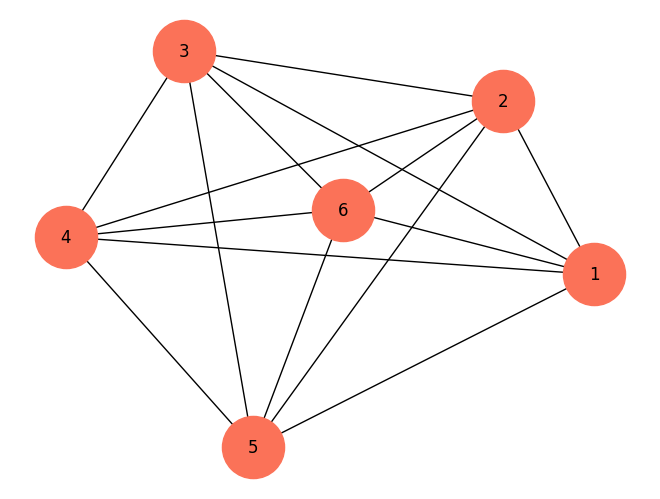

In [29]:
graph = nx.Graph()
graph.add_weighted_edges_from(distances)

nx.draw_kamada_kawai(graph, node_color = '#fb7258', node_size = 2000, with_labels = True)

In [30]:
def edgeLength(i, j, distances, roundTrip = True):
    if roundTrip:
        return max([(item[2] if (item[0] == i and item[1] == j) or (item[1] == i and item[0] == j) else -1)
        for item in distances])
    else:
        return max([(item[2] if (item[0] == i and item[1] == j) else -1) for item in distances])

In [31]:
def routeLength(V, distances):
    edges = []
    for i in range(len(V) - 1):
        edges.append(edgeLength(V[i], V[i + 1], distances))
    return sum(edges)

In [32]:
def routeOneReplacement(arrV, Z, replacementByName = True):
    decrement = 1 if replacementByName else 0

    arrV[Z[0] - decrement], arrV[Z[1] - decrement] = arrV[Z[1] - decrement], arrV[Z[0] - decrement]

    return arrV

In [33]:
def routeReplacement(V, Z):
    for z in Z:
        V = routeOneReplacement(V, z)
    return V

In [34]:
# выбор нужного пути методом отжига
def chooseRoute(distances, V, Z, T, P):
    sumLength = routeLength(V, distances)
    arrSum = [sumLength]

    # циклы методом отжига
    for i in range(len(Z)):
        newV = routeOneReplacement(V[:], Z[i])
        newS = routeLength(newV, distances)
        arrSum.append(newS)
        deltaS = newS - sumLength

        if deltaS > 0:
            p = probability(deltaS, T)
            if p > P[i]:
                V = newV
                sumLength = newS
        else:
            V = newV
            sumLength = newS

        T = reductTemp(T)

    return V, arrSum

In [35]:
def drawRouteGraph(distances, bestRoute):
    newDistances = []
    for i in range(len(bestRoute) - 1):
        for distance in distances:
            if distance[0] == bestRoute[i] and distance[1] == bestRoute[i + 1] or distance[1] == bestRoute[i] and distance[0] == bestRoute[i + 1]:
                newDistances.append(distance)

    graph = nx.Graph()

    graph.add_weighted_edges_from(newDistances)

    nx.draw_kamada_kawai(graph, node_color='#fb7258', node_size=2000, with_labels=True)

Лучший выбранный маршрут: [1, 6, 2, 3, 4, 5, 1]
Длина лучшего выбранного маршрута: 146
Длины всех рассмотренных маршрутов: [189, 209, 186, 146, 166]


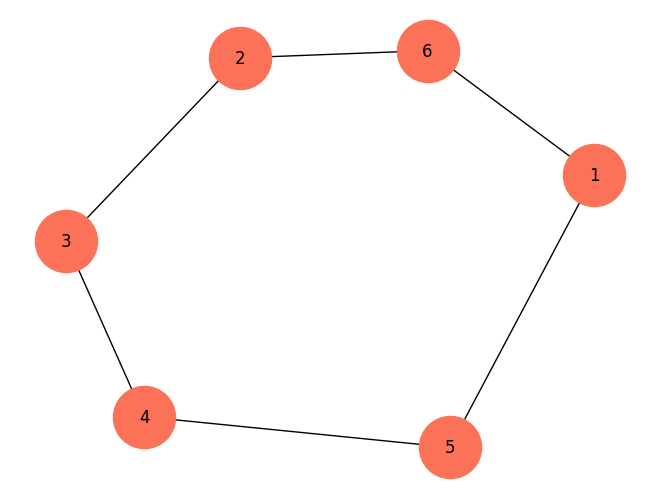

In [36]:
bestRoute, arrLength = chooseRoute(distances, V, Z, T, P)

print(f'Лучший выбранный маршрут: {bestRoute}')
print(f'Длина лучшего выбранного маршрута: {routeLength(bestRoute, distances)}')
print(f'Длины всех рассмотренных маршрутов: {arrLength}')

drawRouteGraph(distances, bestRoute)